<a href="https://colab.research.google.com/github/massimilianogasparini-author/creative-loop-dynamics/blob/main/diagrams/ritratto_di_fase_creative_loop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

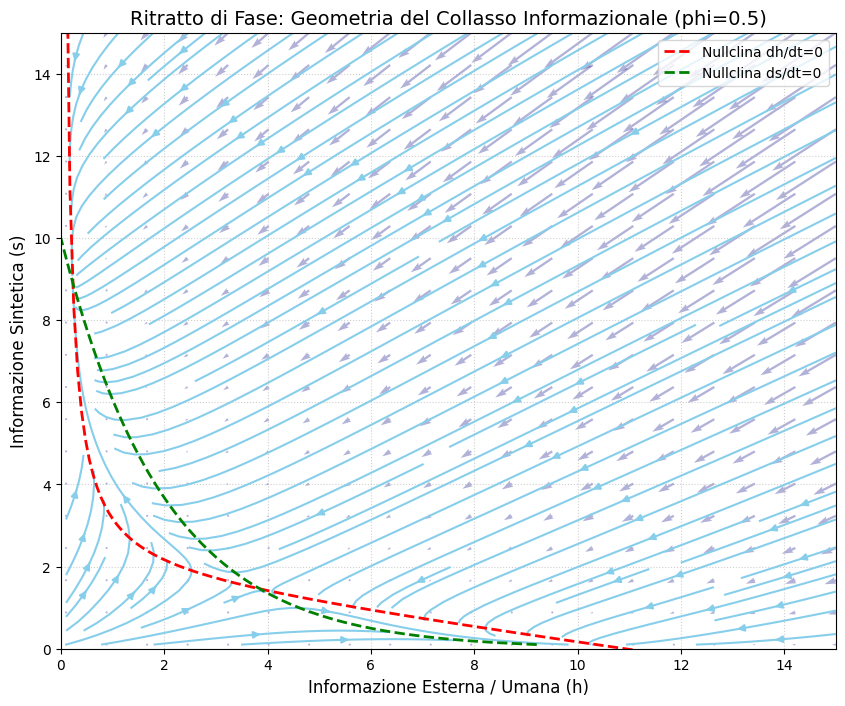

In [1]:
"""
=============================================================================
FILE: ritratto_di_fase_creative_loop.ipynb
FRAMEWORK: Creative Loop (DOI: 10.5281/zenodo.19500843)
AUTORE: Massimiliano Gasparini (ORCID: 0009-0004-4216-4852)
DESCRIZIONE: Analisi del piano di fase (h, s). Visualizzazione dei campi
             vettoriali e identificazione degli attrattori del sistema.
=============================================================================
"""
import numpy as np
import matplotlib.pyplot as plt

# Parametri del sistema h-s
alpha, beta, gamma, lambd_, K, Ks = 0.5, 0.3, 0.4, 0.2, 10, 10
phi = 0.5 # Regime di bassa iniezione (Collasso)

def system(H, S):
    S_safe = np.maximum(S, 1e-6)
    dH = alpha * H * (1 - H/K) - beta * H * S + phi
    dS = gamma * S * np.log(Ks / S_safe) - lambd_ * S * H
    return dH, dS

h_range = np.linspace(0.1, 15, 20)
s_range = np.linspace(0.1, 15, 20)
H, S = np.meshgrid(h_range, s_range)
u, v = system(H, S)

plt.figure(figsize=(10, 8))
plt.streamplot(H, S, u, v, color='skyblue', density=1.5)
plt.quiver(H, S, u, v, color='navy', alpha=0.3)

# Nullclina dH/dt = 0
h_vals = np.linspace(0.1, 15, 200)
s_null_h = (alpha * (1 - h_vals/K) + phi/h_vals) / beta
plt.plot(h_vals, s_null_h, 'r--', label='Nullclina dh/dt=0', linewidth=2)

# Nullclina dS/dt = 0
s_vals = np.linspace(0.1, Ks, 200)
h_null_s = (gamma / lambd_) * np.log(Ks / s_vals)
plt.plot(h_null_s, s_vals, 'g--', label='Nullclina ds/dt=0', linewidth=2)

plt.title('Ritratto di Fase: Geometria del Collasso Informazionale (phi=0.5)', fontsize=14)
plt.xlabel('Informazione Esterna / Umana (h)', fontsize=12)
plt.ylabel('Informazione Sintetica (s)', fontsize=12)
plt.ylim(0, 15)
plt.xlim(0, 15)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()